In [1]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import os
import re
from tqdm import tqdm
from dspeed.processors.trap_filters import trap_norm
from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe,calculate_tail_slope, query_and_plot_waveform
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b
import pickle
import legendstyles

plt.style.use(legendstyles.LEGEND)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) #makes the notebook wider
plt.style.use('default')
import h5py

detector = 'ponama_1' # 'ICPC' 'P42575A' 'UNC_scanner'

# Output from siggen
sim_time=8000
step_time_out = 10
time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))


sim_time_2=16000
step_time_out_2 = 16
time_2 = np.linspace(start=step_time_out_2, stop= sim_time_2, num= (int) (sim_time_2/step_time_out_2))


# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise = 3000 
flat = 2000
pickoff = 4000


100%|██████████| 9/9 [00:07<00:00,  1.14it/s]


Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf'],
      dtype='object')


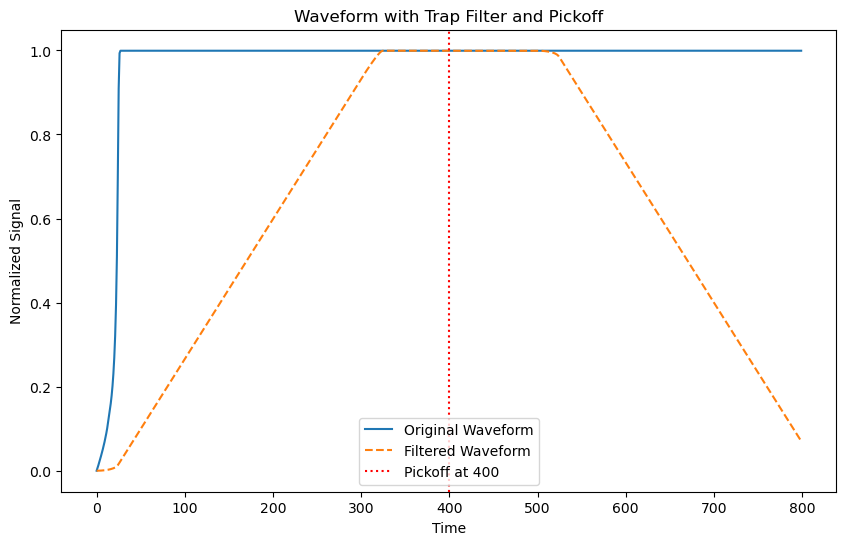

None
Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf', 'energy_estimate'],
      dtype='object')


In [2]:
# Output from siggen
sim_time=8000
step_time_out = 10
time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))
# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise = 3000 
flat = 2000
pickoff = 4000
#This is the data for panoma-1 with 10 ns sampling and 10 us total sim time
directory = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/'

waveforms_df = load_waveform_data(directory)
print(waveforms_df.columns)
# waveforms_df = waveforms_df[waveforms_df['r']>2]

# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise_samp = math.floor(rise/step_time_out)
flat_samp = math.floor(flat/ step_time_out)
pickoff_samp = math.floor(pickoff/step_time_out)
#applies trap filter and gets pickoff value
activeness= compute_pickoff_values_and_plot_random(waveforms_df, rise_samp, flat_samp, pickoff_samp, plot_random=True)
print(activeness)
print(waveforms_df.columns)

100%|██████████| 9/9 [00:07<00:00,  1.14it/s]


Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf'],
      dtype='object')


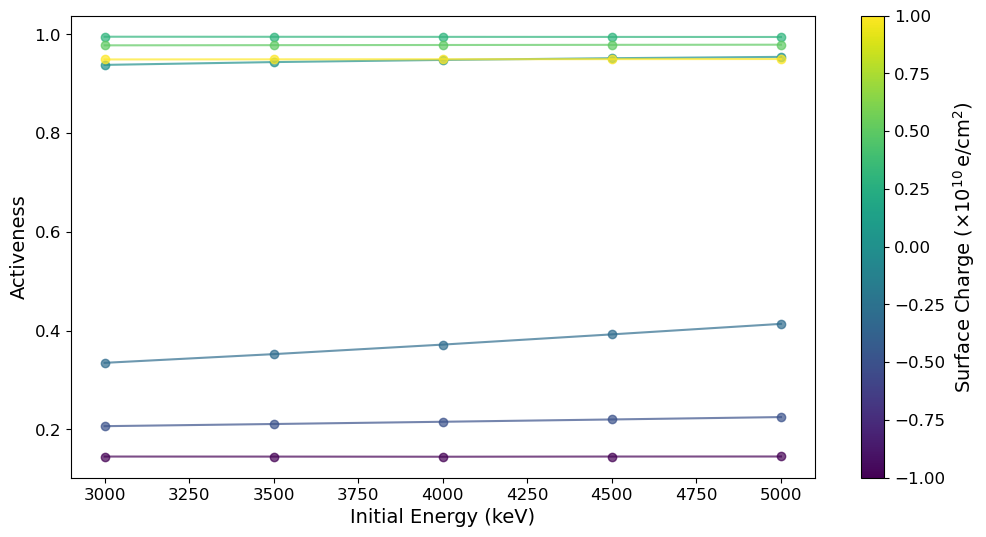

In [3]:
import math
from tools import trap_norm
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as colors
from matplotlib import cm

from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe, calculate_tail_slope, query_and_plot_waveform

# Output from siggen
sim_time=8000
step_time_out = 10
time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))
# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise = 3000 
flat = 2000
pickoff = 4000
#This is the data for panoma-1 with 10 ns sampling and 10 us total sim time
directory = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/'

waveforms_df = load_waveform_data(directory)
print(waveforms_df.columns)
# waveforms_df = waveforms_df[waveforms_df['r']>2]

# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise_samp = math.floor(rise/step_time_out)
flat_samp = math.floor(flat/ step_time_out)
pickoff_samp = math.floor(pickoff/step_time_out)
#applies trap filter and gets pickoff value
activeness= compute_pickoff_values_and_plot_random(waveforms_df, rise_samp, flat_samp, pickoff_samp, plot_random=False)

# Define variables for z position and tolerance
z_target = 1.0  # Target z position in mm
z_tolerance = 0.01  # Tolerance in mm

# Filter the DataFrame for the specified conditions
df_filtered = waveforms_df[
    (waveforms_df['r'] == 14) &
    (waveforms_df['z'].between(z_target - z_tolerance, z_target + z_tolerance)) &
    (waveforms_df['sf_drift'] == 0.001)
]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Normalize surface charge values for colormap
norm = colors.Normalize(vmin=df_filtered['sc'].min(), vmax=df_filtered['sc'].max())
cmap = cm.viridis

# Group data by surface charge and plot each group
for sc_val, group_df in df_filtered.groupby('sc'):
    group_df_sorted = group_df.sort_values('eng')
    ax.plot(group_df_sorted['eng'], group_df_sorted['energy_estimate'],
            marker='o', linestyle='-', label=f'sc={sc_val:.2f}',
            color=cmap(norm(sc_val)), alpha=0.7)

# Add colorbar for surface charge
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Surface Charge ($\\times 10^{10}\\,\\mathrm{e}/\\mathrm{cm}^2$)', fontsize=14)

# Set plot labels and title
ax.set_xlabel('Initial Energy (keV)', fontsize=14)
ax.set_ylabel('Activeness', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
cbar.ax.tick_params(labelsize=12)  # set tick label font size

# ax.set_title(f'Activeness vs. Initial Energy at r=14 mm, z={z_target:.2f} mm', fontsize=14)

# Display the plot
plt.savefig('figs/activness_vs_eng.png')
plt.show()


In [4]:
print(waveforms_df.r.unique())
print(waveforms_df.z.unique())
print(waveforms_df.sc.unique())
print(waveforms_df.eng.unique())

[15.  2.  4. ... 23. 29. 32.]
[0.02 0.   0.2  ... 2.6  2.8  3.  ]
[-0.5  0.   0.3 ...  1.   1.1  1.2]
[5000. 4500. 4000. 3500. 3000.]


100%|██████████| 1/1 [00:04<00:00,  4.22s/it]


Pickoff value at 13000 ns (index 812): 0.85


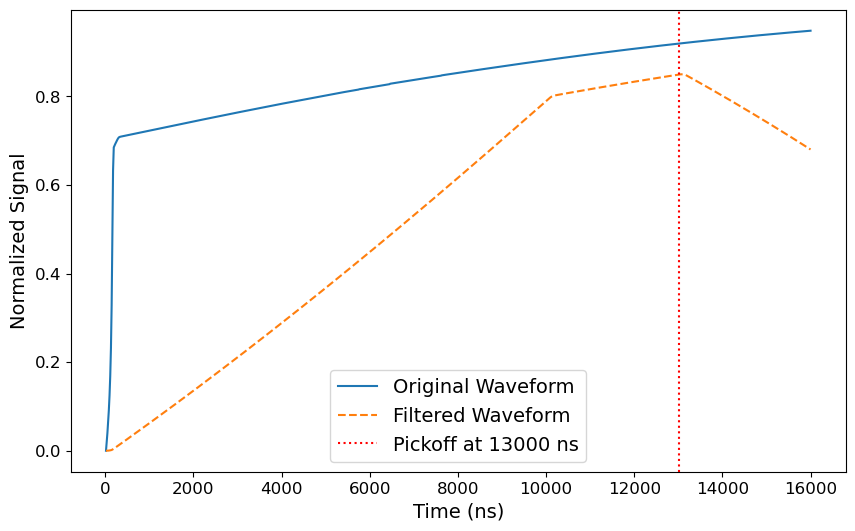

In [5]:
import math
from tools import trap_norm
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe, calculate_tail_slope, query_and_plot_waveform

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

detector = 'ponama_1' # P00698A 
r_exp = 14.00
z_exp = 5.12
sc_exp = -0.5
sd_exp = 0.001
eng_exp = 5000.00
grid_exp = 0.02
sim_time_2 = 16000
step_time_out_2 = 16

# Physical values (ns), will convert to sample indices
rise = 10000 
flat = 3000
pickoff = 13000

# Convert to samples
rise_samp = math.floor(rise / step_time_out_2)
flat_samp = math.floor(flat / step_time_out_2)
pickoff_samp = math.floor(pickoff / step_time_out_2)

# Define time axis
time_2 = np.linspace(start=step_time_out_2, stop=sim_time_2, num=int(sim_time_2 / step_time_out_2))

# Load waveform data
directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'
waveforms_df = load_waveform_data(directory)

# Get specific waveform
specific_waveform = query_and_plot_waveform(waveforms_df, time_2, r_exp, z_exp, sc_exp, sd_exp, eng_exp, detector, grid_exp)

# Apply trapezoidal filter
filtered_wf = np.zeros_like(specific_waveform)
trap_norm(specific_waveform, rise_samp, flat_samp, filtered_wf)

# Compute pickoff value
if pickoff_samp < len(filtered_wf):
    pickoff_val = filtered_wf[pickoff_samp]
    print(f"Pickoff value at {pickoff} ns (index {pickoff_samp}): {pickoff_val:.2f}")
else:
    pickoff_val = np.nan
    print(f"Pickoff time {pickoff} ns (index {pickoff_samp}) out of range.")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(time_2, specific_waveform, label='Original Waveform')
plt.plot(time_2, filtered_wf, label='Filtered Waveform', linestyle='--')
if pickoff_samp < len(time_2):
    plt.axvline(time_2[pickoff_samp], color='r', linestyle=':', label=f'Pickoff at {pickoff} ns')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
# plt.title('Waveform with Trap Filter and Pickoff', fontsize=14)
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('Normalized Signal', fontsize=14)
plt.savefig('figs/trap_example.pdf')
plt.show()


100%|██████████| 1/1 [00:02<00:00,  2.37s/it]


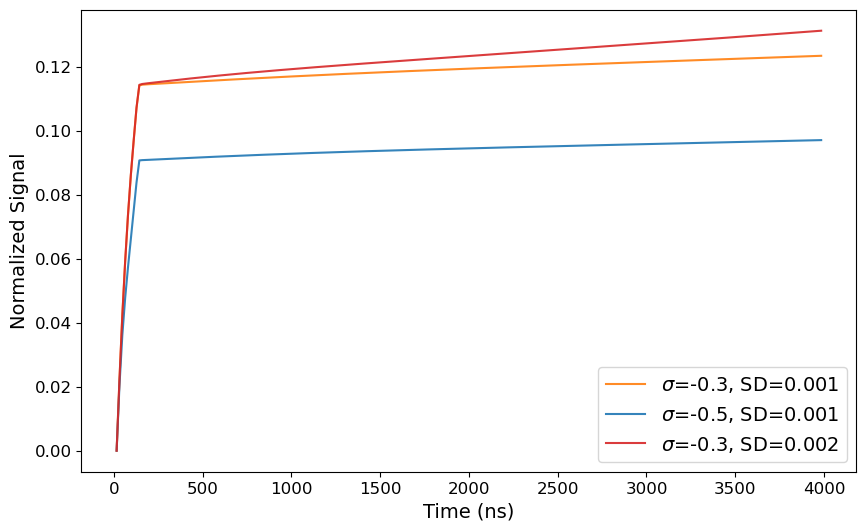

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe,calculate_tail_slope, query_and_plot_waveform

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

detector = 'P00698A'
# Example call to the function for the initial waveform
r_exp = 15.00
z_exp = 0.02
sc_exp = -0.3
sd_exp = 0.001
eng_exp = 5000.00
grid_exp = 0.02
sim_time_2=16000
step_time_out_2 = 16

time_2 = np.linspace(start=step_time_out_2, stop= sim_time_2, num= (int) (sim_time_2/step_time_out_2))


directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'

waveforms_df = load_waveform_data(directory)


specific_waveform = query_and_plot_waveform(waveforms_df, time_2, r_exp, z_exp, sc_exp, sd_exp, eng_exp, detector, grid_exp)
cut = (time_2<4000)

# Plot the initial waveform
plt.figure(figsize=(10, 6))
plt.plot(time_2[cut], specific_waveform[cut], color="tab:orange", alpha=0.9, label=f'$\sigma$={sc_exp}, SD={sd_exp}')

# Plot comparison with SC=-0.5
sc_exp_compare1 = -0.5
sd_exp_compare1 = 0.001
waveform_compare1 = query_and_plot_waveform(waveforms_df, time_2, r_exp, z_exp, sc_exp_compare1, sd_exp_compare1, eng_exp, detector, grid_exp)
plt.plot(time_2[cut], waveform_compare1[cut], color="tab:blue", alpha=0.9, label=f'$\sigma$={sc_exp_compare1}, SD={sd_exp_compare1}')

# Plot comparison with SD=0.002
sc_exp_compare2 = -0.3
sd_exp_compare2 = 0.002
waveform_compare2 = query_and_plot_waveform(waveforms_df, time_2, r_exp, z_exp, sc_exp_compare2, sd_exp_compare2, eng_exp, detector, grid_exp)
plt.plot(time_2[cut], waveform_compare2[cut], color="tab:red", alpha=0.9, label=f'$\sigma$={sc_exp_compare2}, SD={sd_exp_compare2}')

# Labeling and formatting the plot
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('Normalized Signal', fontsize=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
# plt.title(f'Signal Comparison at r={r_exp}, z={z_exp}, eng={eng_exp}', fontsize=18)
plt.legend(fontsize=14)
plt.savefig('figs/wf_comp.pdf')
plt.show()


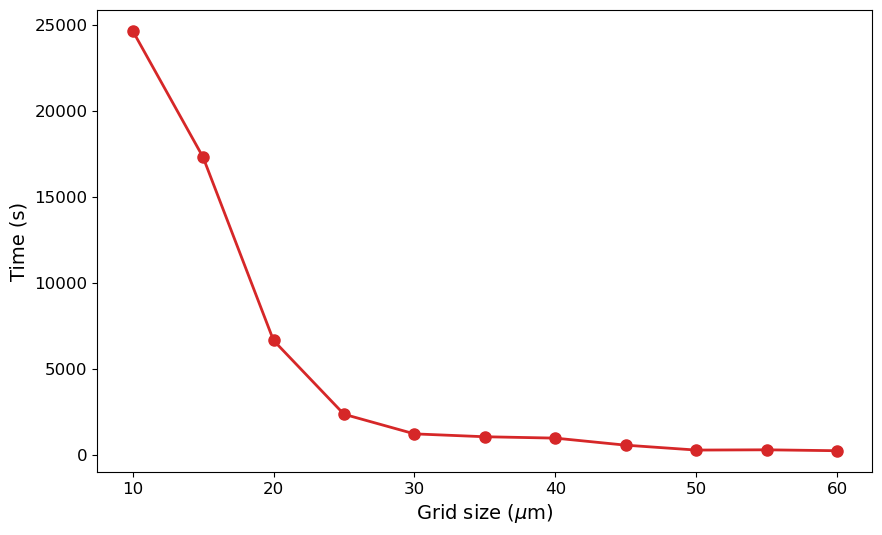

In [7]:
time_full_program_cpu = np.array([24642, 17291, 6648, 2359, 1219, 1052, 972, 562, 278, 293, 240])
time_full_program_gpu = np.array([394, 189, 86, 49, 33, 24, 17, 14, 11, 9, 8])
grid_full_program = np.array([0.010, 0.015, 0.020,0.025,0.030,0.035,0.040,0.045,0.050, 0.055, 0.0600])

# Create a plot with larger dimensions
plt.figure(figsize=(10, 6))

# Plotting the CPU and GPU data with increased markersize and line width
plt.plot(grid_full_program*1000, time_full_program_cpu, 'o-', color='tab:red', markersize=8, linewidth=2)  # Increased markersize

# Increasing font sizes for labels, title, and legend
plt.xlabel('Grid size ($\mu$m)', fontsize=14)  # Increased fontsize
plt.ylabel('Time (s)', fontsize=14)  # Increased fontsize
# plt.title('Time to Run Full Simulation', fontsize=16)

# Tick labels size
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels

# Adding grid lines for better readability
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.minorticks_on()
# plt.grid(True, which='both', linestyle='--', alpha=0.5, linewidth=0.5)

# Save the figure
plt.savefig("figs/cpu_run_time.pdf")

# Display the plot
plt.show()

100%|██████████| 9/9 [00:07<00:00,  1.17it/s]


Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf'],
      dtype='object')
R² (Coefficient of Determination): 0.9687
RMSE (Root Mean Squared Error): 117.22 keV


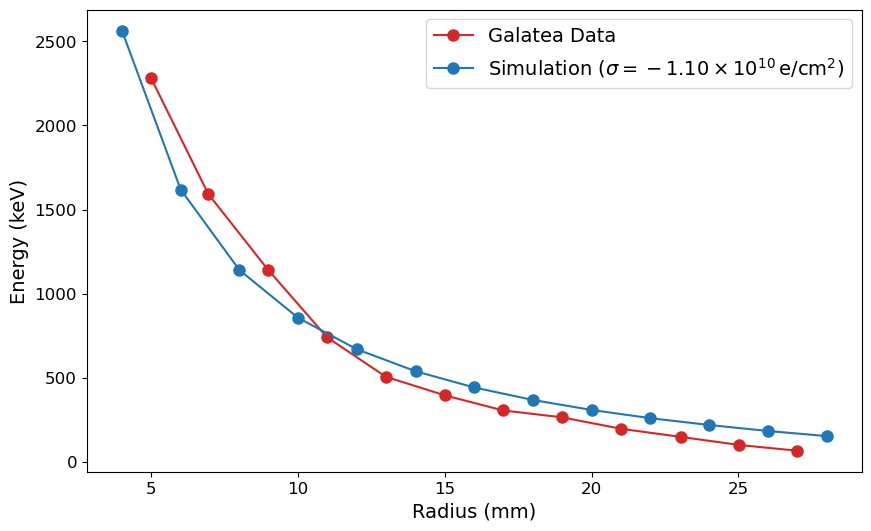

In [8]:
import math
from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe,calculate_tail_slope, query_and_plot_waveform
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
# Load and prepare Galatea data
df_galatea = pd.read_csv('plot_data/galatea_data.csv', header=None)
df_galatea.columns = ['Radius', 'Energy']

# Output from siggen
sim_time=8000
step_time_out = 10
time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))
# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise = 3000 
flat = 2000
pickoff = 4000
#This is the data for panoma-1 with 10 ns sampling and 10 us total sim time
directory = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/'

waveforms_df = load_waveform_data(directory)
print(waveforms_df.columns)
# waveforms_df = waveforms_df[waveforms_df['r']>2]

# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise_samp = math.floor(rise/step_time_out)
flat_samp = math.floor(flat/ step_time_out)
pickoff_samp = math.floor(pickoff/step_time_out)
#applies trap filter and gets pickoff value
activeness= compute_pickoff_values_and_plot_random(waveforms_df, rise_samp, flat_samp, pickoff_samp, plot_random=False)


rad_cut = 4
# Function to perform polynomial regression and calculate RMSE
def fit_and_evaluate(x, y, degree=5):
    poly = PolynomialFeatures(degree=degree)
    x_poly = poly.fit_transform(x[:, np.newaxis])
    model = LinearRegression()
    model.fit(x_poly, y)
    x_fit = np.linspace(df_galatea['Radius'].min(), df_galatea['Radius'].max(), 300)
    y_pred = model.predict(poly.transform(x_fit[:, np.newaxis]))
    rmse = np.sqrt(mean_squared_error(df_galatea['Energy'], model.predict(poly.transform(df_galatea['Radius'].values[:, np.newaxis]))))
    return model, rmse, x_fit, y_pred

# Load your data here as needed
# Assume waveforms_df and df_galatea are already loaded with the necessary preprocessing done

# Variables to store the best fitting results
min_rmse = float('inf')
best_params = None
best_prediction = None
waveforms_df['energy_in_keV'] = waveforms_df['energy_estimate'] * waveforms_df['eng']

# Iterate over unique combinations of surface charge and surface drift
for sc in waveforms_df['sc'].unique():
    for sd in waveforms_df['sf_drift'].unique():
        df_filtered = waveforms_df[(waveforms_df['sc'] == sc) & (waveforms_df['sf_drift'] == sd) & (waveforms_df['r'] >= rad_cut)]
        if df_filtered.empty:
            continue
        df_aggregated = df_filtered.groupby('r').agg({'energy_in_keV': 'mean'}).reset_index()
        model, rmse, x_fit, predictions = fit_and_evaluate(df_aggregated['r'].values, df_aggregated['energy_in_keV'].values)
        if rmse < min_rmse:
            min_rmse = rmse
            best_params = (sc, sd)
            best_prediction = (x_fit, predictions)

# Plot the best results
plt.figure(figsize=(10, 6))
plt.plot(df_galatea['Radius'][df_galatea['Radius']>rad_cut], df_galatea['Energy'][df_galatea['Radius']>rad_cut], marker='o', markersize=8, linestyle='-', color='tab:red', alpha=1, label='Galatea Data')
if best_params:
    plot_df_gal = waveforms_df[(waveforms_df['sc'] == best_params[0]) & (waveforms_df['sf_drift'] == best_params[1]) & (waveforms_df['r'] >= rad_cut)]
    plt.plot(
        plot_df_gal['r'],
        plot_df_gal['energy_in_keV'],
        marker='o',
        linestyle='-',
        markersize=8,
        color="tab:blue",
        alpha=1,
        label=fr'Simulation ($\sigma={best_params[0]:.2f} \times 10^{{10}}\,\mathrm{{e}}/\mathrm{{cm}}^2$)'
    )    # Increase font sizes
    plt.xlabel('Radius (mm)', fontsize=14)  # Add x-axis label if needed
    plt.ylabel('Energy (keV)', fontsize=14)
    # plt.title('Energy collected in GALATEA Scanner', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=12)  # Bigger tick labels
    plt.yticks(fontsize=12)  # Bigger tick labels
    # Add grid lines for better readability
    # plt.grid(True, which='both', linestyle='--', alpha=0.5, linewidth=0.5)
    # plt.minorticks_on()
    plt.savefig("figs/gal_fit.pdf")
# Compute R² and RMSE for the best fit
if best_params:
    # Extract simulation data for the best fit
    df_simulation = waveforms_df[(waveforms_df['sf_drift'] == best_params[1]) & (waveforms_df['sc'] == best_params[0]) & (waveforms_df['r'] >= rad_cut)]
    df_sim_aggregated = df_simulation.groupby('r').agg({'energy_in_keV': 'mean'}).reset_index()

    # Interpolate the simulation results to match the radii of the Galatea data
    interpolated_simulation = np.interp(df_galatea['Radius'][df_galatea['Radius'] > rad_cut], df_sim_aggregated['r'], df_sim_aggregated['energy_in_keV'])

    # Calculate R²
    ss_residual = np.sum((df_galatea['Energy'][df_galatea['Radius'] > rad_cut] - interpolated_simulation) ** 2)
    ss_total = np.sum((df_galatea['Energy'][df_galatea['Radius'] > rad_cut] - df_galatea['Energy'][df_galatea['Radius'] > rad_cut].mean()) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(df_galatea['Energy'][df_galatea['Radius'] > rad_cut], interpolated_simulation))

    # Print the metrics
    print(f"R² (Coefficient of Determination): {r_squared:.4f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f} keV")
else:
    print("No best fit parameters found.")


In [9]:
import pandas as pd

# Load the data from the text file
data = pd.read_csv(directory + 'E_fitResults_062317.txt', sep='\s+', dtype={'DS': str}, index_col=False)

# Calculate the radius in mm
data['Radius'] = data['DS'].str.split('_').str[0].astype(int) / 10 - 20
data['Radius'] = data['Radius'] * 1.5

# Define the radius cutoff
rad_cut = 6

# Filter positive radii that are greater than or equal to the cutoff
positive_radius = data[(data['Radius'] >= rad_cut)].copy()

# Initialize an empty list to store the processed rows
processed_data = []

# Handle each radius case specifically
# For radius = 30, use only DS400_0
processed_data.append(positive_radius[positive_radius['DS'] == '400_0'])

# For radius = 24, average all the points
radius_24 = positive_radius[positive_radius['Radius'] == 24.0]
processed_data.append(radius_24.mean(numeric_only=True).to_frame().T.assign(Radius=24.0))

# For radius = 9, average all the points
radius_9 = positive_radius[positive_radius['Radius'] == 9.0]
processed_data.append(radius_9.mean(numeric_only=True).to_frame().T.assign(Radius=9.0))

# For radius = 15, use DS300_0 and DS300_1
radius_15 = positive_radius[positive_radius['DS'].isin(['300_0', '300_1'])]
processed_data.append(radius_15.mean(numeric_only=True).to_frame().T.assign(Radius=15.0))

# For radius = 16.5, use DS310_0 and DS310_1
radius_16_5 = positive_radius[positive_radius['DS'].isin(['310_0', '310_1'])]
processed_data.append(radius_16_5.mean(numeric_only=True).to_frame().T.assign(Radius=16.5))

# For radius = 19.5, average DS330
radius_19_5 = positive_radius[positive_radius['Radius'] == 19.5]
processed_data.append(radius_19_5.mean(numeric_only=True).to_frame().T.assign(Radius=19.5))

# For radius = 21.0, average DS340
radius_21_0 = positive_radius[positive_radius['Radius'] == 21.0]
processed_data.append(radius_21_0.mean(numeric_only=True).to_frame().T.assign(Radius=21.0))

# For radius = 22.5, use DS350_0 and DS350_1
radius_22_5 = positive_radius[positive_radius['DS'].isin(['350_0', '350_1'])]
processed_data.append(radius_22_5.mean(numeric_only=True).to_frame().T.assign(Radius=22.5))

# Add other radii without duplicates
unique_radii = positive_radius.loc[~positive_radius['Radius'].duplicated(keep=False)]
processed_data.append(unique_radii)

# Combine all the processed rows into a single DataFrame
final_data = pd.concat(processed_data, ignore_index=True)

# Drop duplicates and reset index
final_data = final_data.drop_duplicates(subset=['Radius']).reset_index(drop=True)
final_data = final_data[['Radius', 'Mu']].rename(columns={'Mu': 'Energy'})

# Display the processed DataFrame
print(final_data)


    Radius  Energy
0     30.0  4694.0
1     24.0  4499.5
2      9.0  3518.0
3     15.0  4085.5
4     16.5  4189.5
5     19.5  4359.0
6     21.0  4435.0
7     22.5  4468.0
8      7.5  3341.0
9     10.5  3689.0
10    12.0  3863.0
11    13.5  3992.0
12    18.0  4288.0
13    25.5  4544.0
14    27.0  4583.0
15    28.5  4636.0


/tmp/ipykernel_1124802/2718684368.py:4: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  data = pd.read_csv(directory + 'E_fitResults_062317.txt', sep='\s+', dtype={'DS': str}, index_col=False)


100%|██████████| 9/9 [00:07<00:00,  1.16it/s]


Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf'],
      dtype='object')


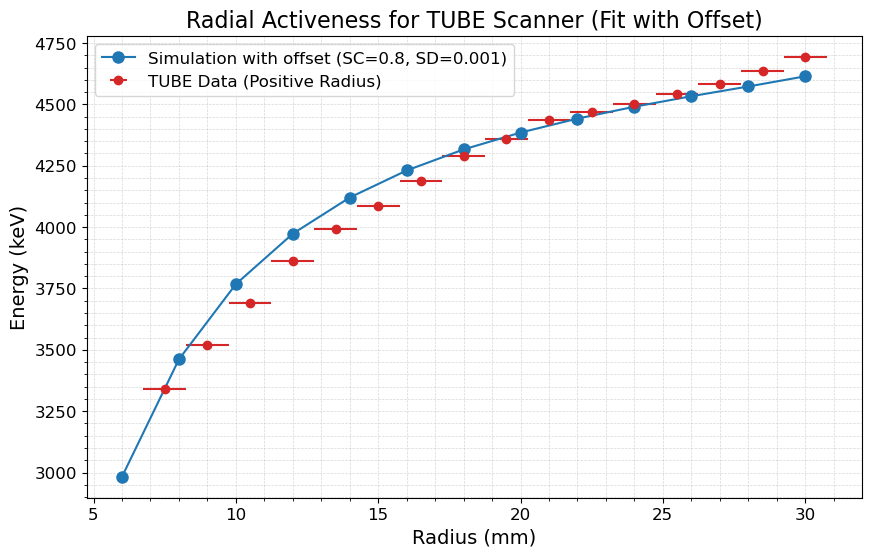

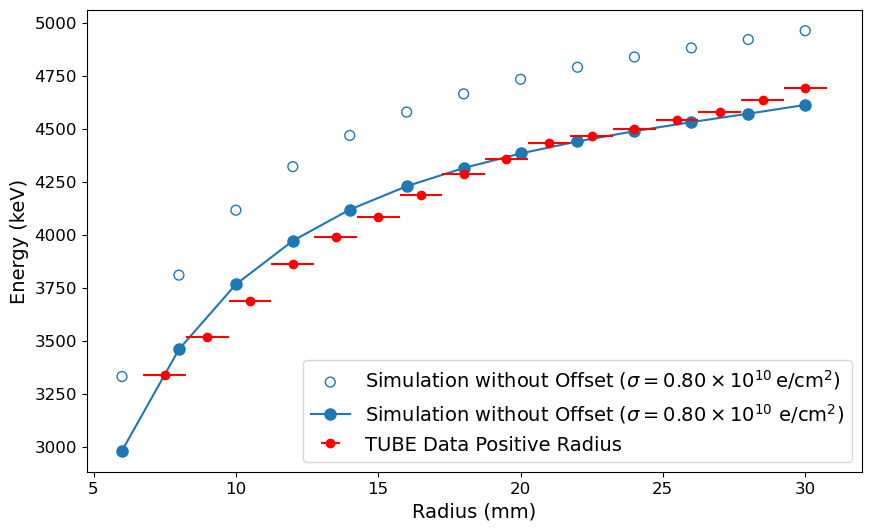

R² (Coefficient of Determination): -0.5140
RMSE (Root Mean Squared Error): 494.39 keV


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# Output from siggen
sim_time=8000
step_time_out = 10
time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))
# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise = 3000 
flat = 2000
pickoff = 4000
#This is the data for panoma-1 with 10 ns sampling and 10 us total sim time
directory = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/'

waveforms_df = load_waveform_data(directory)
print(waveforms_df.columns)
# waveforms_df = waveforms_df[waveforms_df['r']>2]

# Parameters for the trapezoidal filter, since we out put every 10 ns, 300 rise time would correspond to 3000us in real time
rise_samp = math.floor(rise/step_time_out)
flat_samp = math.floor(flat/ step_time_out)
pickoff_samp = math.floor(pickoff/step_time_out)
#applies trap filter and gets pickoff value
activeness= compute_pickoff_values_and_plot_random(waveforms_df, rise_samp, flat_samp, pickoff_samp, plot_random=False)




# Define the radius cutoff and offsets
rad_cut = 6
energy_offset = -350
radius_offset = 2.0

# Filter the final data for positive radii greater than rad_cut
final_data = final_data[(final_data['Radius'] >= rad_cut)].copy()

# Function to perform polynomial regression and calculate RMSE
def fit_and_evaluate(x, y, degree=5):
    poly = PolynomialFeatures(degree=degree)
    x_poly = poly.fit_transform(x[:, np.newaxis])
    model = LinearRegression()
    model.fit(x_poly, y)
    x_fit = np.linspace(final_data['Radius'].min(), final_data['Radius'].max(), 300)
    y_pred = model.predict(poly.transform(x_fit[:, np.newaxis]))
    rmse = np.sqrt(mean_squared_error(final_data['Energy'], model.predict(poly.transform(final_data['Radius'].values[:, np.newaxis]))))
    return model, rmse, x_fit, y_pred

# Apply energy and radius offsets for finding the best fit
waveforms_df['energy_in_keV'] = waveforms_df['energy_estimate'] * waveforms_df['eng'] + energy_offset
waveforms_df['radius_with_offset'] = waveforms_df['r'] + radius_offset

# Variables to store the best fitting results
min_rmse = float('inf')
best_params = None
best_prediction = None

# Iterate over unique combinations of surface charge and surface drift to find the best fit
for sc in waveforms_df['sc'].unique():
    for sd in waveforms_df['sf_drift'].unique():
        df_filtered = waveforms_df[(waveforms_df['sc'] == sc) & (waveforms_df['sf_drift'] == sd) & (waveforms_df['radius_with_offset'] >= rad_cut)]
        if df_filtered.empty:
            continue
        df_aggregated = df_filtered.groupby('radius_with_offset').agg({'energy_in_keV': 'mean'}).reset_index()
        model, rmse, x_fit, predictions = fit_and_evaluate(df_aggregated['radius_with_offset'].values, df_aggregated['energy_in_keV'].values, degree=2)
        if rmse < min_rmse:
            min_rmse = rmse
            best_params = (sc, sd)
            best_prediction = (x_fit, predictions)

# Plot the best fit results (with offset applied) and add error bars to TUBE data
plt.figure(figsize=(10, 6))

# Plot TUBE data with horizontal error bars using `final_data`
plt.errorbar(final_data['Radius'], final_data['Energy'], xerr=0.75, fmt='o', color='tab:red', alpha=1, label='TUBE Data (Positive Radius)')

# Plot the simulation data points
if best_params:
    plot_df = waveforms_df[(waveforms_df['sc'] == best_params[0]) & (waveforms_df['sf_drift'] == best_params[1]) & (waveforms_df['radius_with_offset'] >= rad_cut)]
    plt.plot(plot_df['radius_with_offset'], plot_df['energy_in_keV'], marker='o', markersize=8, color="tab:blue", alpha=1, label=f'Simulation with offset (SC={best_params[0]}, SD={best_params[1]})')


# Customize the plot
plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Energy (keV)', fontsize=14)
plt.title('Radial Activeness for TUBE Scanner (Fit with Offset)', fontsize=16)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5, linewidth=0.5)
plt.minorticks_on()
plt.show()

# Remove the offsets for final plotting
waveforms_df['energy_in_keV'] = waveforms_df['energy_estimate'] * waveforms_df['eng']
waveforms_df['radius_with_offset'] = waveforms_df['r']  # Reset to original radius
sc_best, sd_best = best_params

# Final plot with the best parameters, using only positive radii for simulation and radii > rad_cut
plt.figure(figsize=(10, 6))
df_filtered = waveforms_df[(waveforms_df['sf_drift'] == sd_best) & (waveforms_df['sc'] == sc_best) & (waveforms_df['r'] >= rad_cut-radius_offset)]
if not df_filtered.empty:
    # plt.plot(df_filtered['r']+radius_offset, df_filtered['energy_in_keV'], marker='o', markersize=8, linestyle='-', color="tab:blue", alpha=1, 
    #          label=f'Simulation SC={sc_best}, SD={sd_best}')
    plt.scatter(
        df_filtered['r'] + radius_offset,
        df_filtered['energy_in_keV'],
        edgecolor="tab:blue",
        facecolor='none',
        s=50,
        alpha=1,
        label=r'Simulation without Offset ($\sigma = {:.2f} \times 10^{{10}}\,\mathrm{{e/cm^2}}$)'.format(best_params[0])
    )
    plt.plot(
        plot_df['radius_with_offset'], 
        plot_df['energy_in_keV'], marker='o', 
        markersize=8, color="tab:blue", 
        alpha=1, 
        label=r'Simulation without Offset ($\sigma=%.2f \times 10^{10}\ \mathrm{e/cm^2}$)' % best_params[0]
    )

# Plot TUBE data for comparison, restricted to radii > rad_cut with horizontal error bars
plt.errorbar(final_data['Radius'], final_data['Energy'], xerr=0.75, fmt='o', color='red', alpha=1, label='TUBE Data Positive Radius')
# Customize plot appearance
plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Energy (keV)', fontsize=14)
plt.legend(loc='lower right', fontsize=14)
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
plt.savefig("figs/tube_fit.pdf")
plt.show()
# Compute R² and RMSE for the best fit
if best_params:
    # Extract simulation data for the best fit
    df_simulation = waveforms_df[(waveforms_df['sf_drift'] == sd_best) & (waveforms_df['sc'] == sc_best) & (waveforms_df['r'] >= rad_cut)]
    df_sim_aggregated = df_simulation.groupby('r').agg({'energy_in_keV': 'mean'}).reset_index()

    # Interpolate the simulation results to match the radii of the final data
    interpolated_simulation = np.interp(final_data['Radius'], df_sim_aggregated['r'], df_sim_aggregated['energy_in_keV'])

    # Calculate R²
    ss_residual = np.sum((final_data['Energy'] - interpolated_simulation) ** 2)
    ss_total = np.sum((final_data['Energy'] - final_data['Energy'].mean()) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(final_data['Energy'], interpolated_simulation))

    # Print the metrics
    print(f"R² (Coefficient of Determination): {r_squared:.4f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f} keV")
else:
    print("No best fit parameters found.")

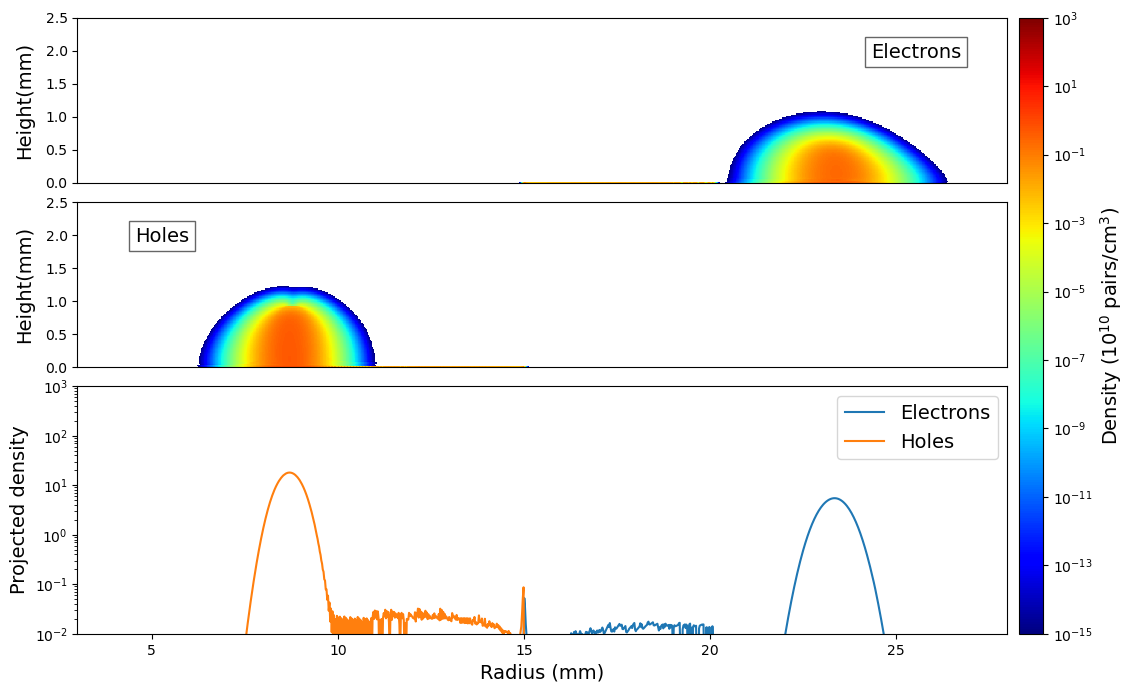

In [11]:
import os
import numpy as np
import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
# commands ran: ./ehdrift config_files/siggen_configs/P00698A_siggen.config -p 1 -g P00698A -s -0.30 -h 0.0200
# ./ehdrift config_files/siggen_configs/P00698A_siggen.config -r 15.00 -z 0.02 -p 0 -g P00698A -s -0.30 -e 5000.00 -c 0.001 -h 0.0200 -v 1 -f 1 -t 16000 -u 16
# Settings for the snapshot
det_plot='P00698A'
r_int = 15.00
z_int = 0.02
sc_int = 0.00 #-0.30 0.3
eng_int = 5000.00
grid_int = 0.0200
fname1 = 'ed005.dat'
fname2 = "h" + fname1[1:]
file_load = f'/work/users/k/b/kbhimani/EH-Drift_data/density_det={det_plot}_r={r_int:.2f}_z={z_int:.2f}_eng={eng_int:.2f}_sc={sc_int:.2f}_grid={grid_int:.4f}/'
plot_title = f"Event at r={r_int}mm, z={z_int}mm, surface charge={sc_int} grid={grid_int}mm"

# Plot settings
r_1, r_2, z_1, z_2 = 3, 28, 0, 2.5
fig_x, fig_y = 12, 8
z_index = 2

# Load data for electron density
data = np.loadtxt(file_load + fname1)
x = np.unique(data[:, 0])
y = np.unique(data[:, 1])
z = data[:, z_index]
zvals = z.reshape(len(x), len(y))
zvals[zvals < 1.1e-15] = 0
zvals = zvals.T

# Load data for hole density
data2 = np.loadtxt(file_load + fname2)
x2 = np.unique(data2[:, 0])
y2 = np.unique(data2[:, 1])
z2 = data2[:, z_index]
zvals2 = z2.reshape(len(x2), len(y2))
zvals2[zvals2 < 1.1e-15] = 0
zvals2 = zvals2.T

# Create a gridspec layout with taller bottom plot
fig = plt.figure(figsize=(fig_x, fig_y))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1.5], hspace=0.1)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Set normalization and colormap
norm = colors.LogNorm(vmin=1.0e-15, vmax=1.0e3)
cmap = 'jet'

# Create plots using pcolormesh
im1 = ax1.pcolormesh(x, y, zvals, norm=norm, cmap=cmap, shading='auto')
im2 = ax2.pcolormesh(x2, y2, zvals2, norm=norm, cmap=cmap, shading='auto')

# Explicitly set the same x and y limits for all axes
ax1.set_xlim(r_1, r_2)
ax1.set_ylim(z_1, z_2)
ax2.set_xlim(r_1, r_2)
ax2.set_ylim(z_1, z_2)
ax3.set_xlim(r_1, r_2)

# Remove x-axis tick labels from top and middle plots
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Set labels and titles
ax1.set_ylabel("Height(mm)", labelpad=8, size=14)
# ax1.set_title(plot_title, fontsize=14)
ax3.set_xlabel("Radius (mm)", size=14)
ax3.set_ylabel("Projected density", size=14)
ax2.set_ylabel("Height(mm)", labelpad=8, size=14)

# Add text labels inside the plots at the top right
ax1.text(0.95, 0.85, 'Electrons', horizontalalignment='right', verticalalignment='top', transform=ax1.transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.6))
ax2.text(0.12, 0.85, 'Holes', horizontalalignment='right', verticalalignment='top', transform=ax2.transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.6))

# Plot projections
xx = np.arange(len(x)) * max(x) / len(x)
zz1 = zvals.sum(axis=0)
zz2 = zvals2.sum(axis=0)
ax3.semilogy(xx, zz1, '-', label='Electrons')
ax3.semilogy(xx, zz2, '-', label='Holes')
ax3.set_ylim(0.01, 1000)
ax3.legend(fontsize=14)

# Add single color bar for both subplots
cbar_ax = fig.add_axes([0.91, 0.11, 0.02, 0.77])  # Position: [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label(r'Density ($10^{10}$ pairs/cm$^3$)', fontsize=14)
# plt.savefig('figs/drift_path.png', facecolor=fig.get_facecolor(), edgecolor='none', dpi=100)
plt.savefig(f'figs/drift_path_sc={sc_int}.png', facecolor=fig.get_facecolor(), edgecolor='none', dpi=300, bbox_inches='tight')

plt.show()
plt.close(fig)


In [12]:
# #Adpated from dsp package
# def trap_norm(w_in: np.ndarray, rise: int, flat: int, w_out: np.ndarray) -> None:
#     w_out[:] = np.nan  # Initialize output waveform with NaNs

#     # Check if input waveform is too short
#     if len(w_in) < rise:
#         return  # Possibly handle this case differently depending on needs

#     # Initial processing
#     w_out[0] = w_in[0] / rise
#     end_idx = min(len(w_in), rise)
#     for i in range(1, end_idx):
#         w_out[i] = w_out[i - 1] + w_in[i] / rise

#     # Handling the flat part
#     end_idx = min(len(w_in), rise + flat)
#     for i in range(rise, end_idx):
#         w_out[i] = w_out[i - 1] + (w_in[i] - w_in[i - rise]) / rise

#     # Decrease part
#     end_idx = min(len(w_in), 2 * rise + flat)
#     for i in range(rise + flat, end_idx):
#         if i - rise - flat >= 0:
#             w_out[i] = w_out[i - 1] + (w_in[i] - w_in[i - rise] - w_in[i - rise - flat]) / rise

#     # Final part
#     for i in range(2 * rise + flat, len(w_in)):
#         w_out[i] = (w_out[i - 1] + (w_in[i] - w_in[i - rise] - w_in[i - rise - flat] + w_in[i - 2 * rise - flat]) / rise)


{'surface_charges': [-0.3, -0.15, -0.03, 0.0, 0.03, 0.15, 0.3], 'efficiency_results': {'V07647A': [0.9981375771601496, 0.9981375771601496, 0.9981375771601496, 0.9981375771601496, 0.9981375771601496, 0.9981375771601496, 0.9981375771601496], 'ponama_1': [0.8402206870655106, 0.8804552402127072, 0.9541679469817803, 0.9914046579216127, 0.9998534290023171, 0.9988284207911422, 0.9972022388370917], 'P00698A': [0.9533445596349179, 0.9716815720356564, 0.9878432978200954, 0.9993326149340321, 0.9999546518117968, 0.9993207875559816, 0.99760605547492]}}


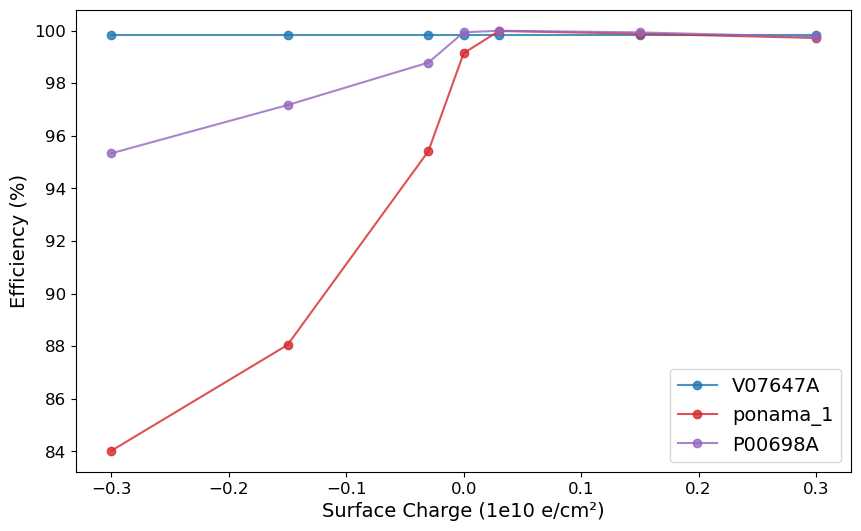

In [13]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

efficiency_file = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/efficiency_results.pkl"

# Load the saved results
with open(efficiency_file, "rb") as f:
    loaded_results = pickle.load(f)
print(loaded_results)
# Access surface charges and efficiency results
loaded_surface_charges = loaded_results["surface_charges"]
loaded_efficiency_results = loaded_results["efficiency_results"]

# Define colors for the detectors
colors = ['tab:blue', 'tab:red', 'tab:purple']
detector_labels = ['V07647A', 'ponama_1', 'P00698A']  # Custom labels

# Plot Efficiency vs. Surface Charge
plt.figure(figsize=(10, 6))
for i, (detector, efficiencies) in enumerate(loaded_efficiency_results.items()):
    plt.plot(loaded_surface_charges, np.array(efficiencies) * 100, 'o-', color=colors[i], alpha=0.8, label=detector_labels[i])

# Set labels, title, and legend
plt.xlabel("Surface Charge (1e10 e/cm²)", fontsize=14)
plt.ylabel("Efficiency (%)", fontsize=14)
# plt.title("Efficiency vs. Surface Charge for Different Detectors", fontsize=16)
plt.legend(fontsize=14, loc='best')  # Place legend in the best position
plt.xticks(fontsize=12)  # Bigger tick labels
plt.yticks(fontsize=12)  # Bigger tick labels
# Save and show the plot
plt.savefig("figs/efficiency_0nbb.pdf")
plt.show()


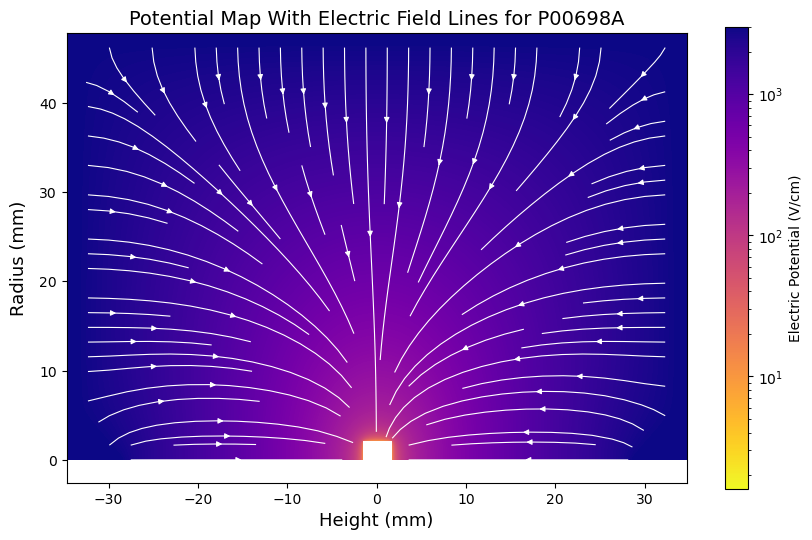

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'
detector = 'P00698A'  # Example detector name

# Load data
data = np.loadtxt(field_dir + f'ev_fin_{detector}_grid=0.0200_sc=0.0000.dat')

# Extract unique grid points and field data
x = np.unique(data[:, 0])  # Radial positions
y = np.unique(data[:, 1])  # Axial positions
z = data[:, 2]             # Potential values
E_r = data[:, 4]           # Radial electric field
E_z = data[:, 5]           # Axial electric field
 
# Reshape data
zvals = z.reshape(len(x), len(y))
zvals[zvals < 0] = 0  # Replace negative values with 0

# **Fix: Set near-zero values to NaN to remove grainy areas**
zvals[zvals <= 1e-10] = np.nan  # Adjust threshold if needed

# Create a symmetric potential map
zvals_neg = np.fliplr(zvals.T)  # Mirror for negative r-values
zvals_full = np.hstack((zvals_neg, zvals.T))  # Concatenate for full symmetry

# Extend the field values symmetrically
E_r_vals = E_r.reshape(len(x), len(y)).T
E_r_full = np.hstack((-np.fliplr(E_r_vals), E_r_vals))  # Symmetric radial field
E_z_vals = E_z.reshape(len(x), len(y)).T
E_z_full = np.hstack((np.fliplr(E_z_vals), E_z_vals))  # Symmetric axial field

# Create new symmetric grid
x_full = np.linspace(-max(x), max(x), 2 * len(x))  # Symmetric, strictly increasing
y_full = y  # Axial positions remain unchanged
X, Y = np.meshgrid(x_full, y_full)  # Meshgrid for the symmetric grid

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# **Fix: Use a colormap that properly handles NaNs**
cmap = plt.cm.plasma_r.copy()
cmap.set_bad(color='white')  # Hide NaN regions

# Plot potential map with smoother interpolation
bounds = (-1 * max(x), max(x), min(y), max(y))
ip = ax.imshow(zvals_full, norm=colors.LogNorm(),
               extent=bounds, origin="lower", cmap=cmap,
               interpolation='bilinear')  # **Fix: Smooth interpolation**

# Add colorbar
cbar = plt.colorbar(ip, label="Electric Potential (V/cm)", ax=ax)
cbar.ax.set_ylim(cbar.vmin, cbar.vmax)  # Ensure it matches the plot height

# Overlay electric field lines
ax.streamplot(X, Y, E_r_full, E_z_full,
              color='white', linewidth=0.8, density=1, arrowsize=0.8)

# Add labels and title
plt.xlabel("Height (mm)", size=13)
plt.ylabel("Radius (mm)", labelpad=8,  size=13)
plt.title(f"Potential Map With Electric Field Lines for {detector}", size=14)

# Save and show
plt.savefig(f'figs/elect_pot_{detector}.pdf', dpi=100)
plt.show()


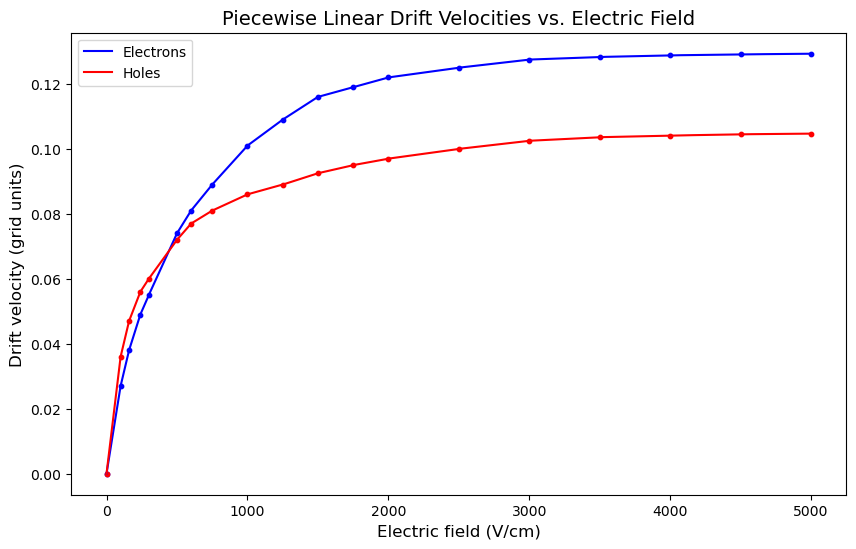

In [15]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Define the arrays
# -----------------------------
drift_E = np.array([
    0.000, 100., 160., 240., 300., 500., 600.,
    750., 1000., 1250., 1500., 1750., 2000., 2500.,
    3000., 3500., 4000., 4500., 5000.
], dtype=float)

drift_offset_e = np.array([
    0.0,   0.027, 0.038, 0.049, 0.055, 0.074, 0.081,
    0.089, 0.101, 0.109, 0.116, 0.119, 0.122, 0.125,
    0.1275, 0.1283, 0.1288, 0.1291, 0.1293
], dtype=float)

drift_offset_h = np.array([
    0.0,   0.036, 0.047, 0.056, 0.06,  0.072, 0.077,
    0.081, 0.086, 0.089, 0.0925, 0.095, 0.097, 0.1,
    0.1025, 0.1036, 0.1041, 0.1045, 0.1047
], dtype=float)

# We will compute the slopes for each interval: slope[i] = (offset[i+1] - offset[i]) / (E[i+1] - E[i]).
# For convenience, we'll create arrays of length 19 (one for each sub-interval).
drift_slope_e = np.zeros(len(drift_E) - 1, dtype=float)
drift_slope_h = np.zeros(len(drift_E) - 1, dtype=float)

for i in range(len(drift_E) - 1):
    dE = drift_E[i+1] - drift_E[i]
    drift_slope_e[i] = (drift_offset_e[i+1] - drift_offset_e[i]) / dE
    drift_slope_h[i] = (drift_offset_h[i+1] - drift_offset_h[i]) / dE

# -----------------------------
# 2) Define a function to get piecewise drift velocity
# -----------------------------
def piecewise_drift_velocity(E, E_array, offset_array, slope_array):
    """
    Returns the drift velocity at field E using piecewise linear segments
    defined by E_array, offset_array, and slope_array.
    
    E_array has length N,
    offset_array and slope_array each have length N (or N-1).
    """
    # If E is below the first breakpoint, return the first offset
    if E < E_array[0]:
        return offset_array[0]
    # If E exceeds the last midpoint, just return the final offset
    if E >= E_array[-1]:
        return offset_array[-1]
    
    # Otherwise, find the segment for E_array[i] <= E < E_array[i+1]
    # We'll do a simple linear search here.
    for i in range(len(E_array) - 1):
        if E >= E_array[i] and E < E_array[i+1]:
            return offset_array[i] + slope_array[i]*(E - E_array[i])
    
    # Fallback (should not happen if arrays are well-defined)
    return offset_array[-1]

# -----------------------------
# 3) Generate a fine grid of fields for plotting
# -----------------------------
E_plot = np.linspace(0, 5000, 500)  # from 0 to 5000 V/cm in 500 steps

# Compute piecewise velocities for electrons and holes
vE_e = [piecewise_drift_velocity(e, drift_E, drift_offset_e, drift_slope_e) for e in E_plot]
vE_h = [piecewise_drift_velocity(e, drift_E, drift_offset_h, drift_slope_h) for e in E_plot]

# -----------------------------
# 4) Plot the results
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(E_plot, vE_e, label='Electrons', color='blue')
plt.plot(E_plot, vE_h, label='Holes', color='red')

# Optionally, plot the raw breakpoints as well
plt.scatter(drift_E, drift_offset_e, color='blue', s=10, marker='o')
plt.scatter(drift_E, drift_offset_h, color='red', s=10, marker='o')

plt.title("Piecewise Linear Drift Velocities vs. Electric Field", fontsize=14)
plt.xlabel("Electric field (V/cm)", fontsize=12)
plt.ylabel("Drift velocity (grid units)", fontsize=12)
# plt.ylim(0, 0.14)  # optional: set y-axis limit to see detail
# plt.ylim(0, 0.01)  # optional: set y-axis limit to see detail
plt.legend()
# plt.grid(True)
plt.savefig('figs/ehd_dv_e.pdf')
plt.show()


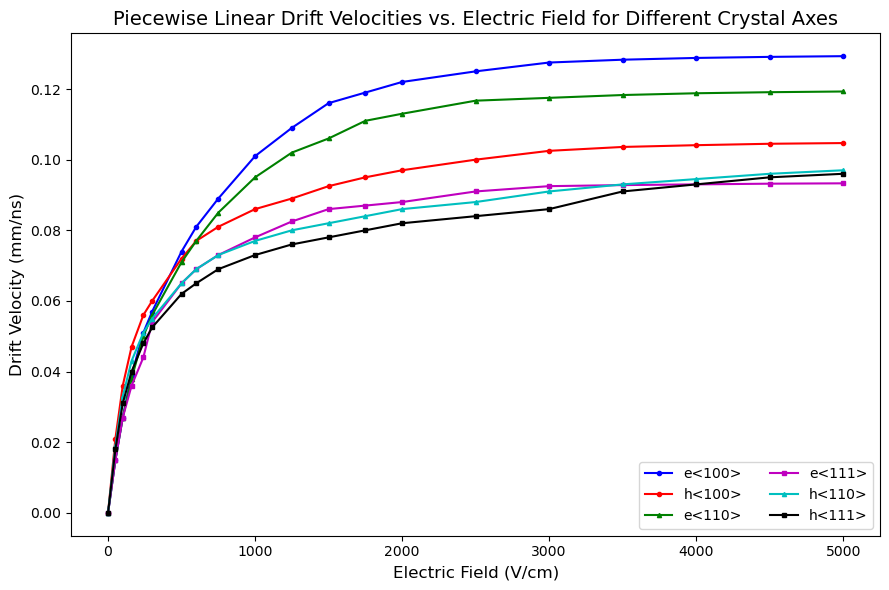

In [16]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt

############################################################################
# 1) PIECEWISE e<100>, h<100>
############################################################################

drift_E = np.array([
    0.0,   100., 160., 240., 300., 500., 600.,
    750., 1000., 1250., 1500., 1750., 2000., 2500.,
    3000., 3500., 4000., 4500., 5000.
], dtype=float)

drift_offset_e = np.array([
    0.0,   0.027, 0.038, 0.049, 0.055, 0.074, 0.081,
    0.089, 0.101, 0.109, 0.116, 0.119, 0.122, 0.125,
    0.1275,0.1283,0.1288,0.1291,0.1293
], dtype=float)

drift_offset_h = np.array([
    0.0,   0.036, 0.047, 0.056, 0.060, 0.072, 0.077,
    0.081, 0.086, 0.089, 0.0925,0.095, 0.097, 0.100,
    0.1025,0.1036,0.1041,0.1045,0.1047
], dtype=float)

# Compute slopes for each sub-interval
drift_slope_e = np.zeros(len(drift_E) - 1, dtype=float)
drift_slope_h = np.zeros(len(drift_E) - 1, dtype=float)
for i in range(len(drift_E) - 1):
    dE = drift_E[i+1] - drift_E[i]
    drift_slope_e[i] = (drift_offset_e[i+1] - drift_offset_e[i]) / dE
    drift_slope_h[i] = (drift_offset_h[i+1] - drift_offset_h[i]) / dE

def piecewise_drift_velocity(E, E_array, offset_array, slope_array):
    """Returns the drift velocity at field E via piecewise linear segments."""
    if E < E_array[0]:
        return offset_array[0]
    if E >= E_array[-1]:
        return offset_array[-1]
    for i in range(len(E_array) - 1):
        if E_array[i] <= E < E_array[i+1]:
            return offset_array[i] + slope_array[i]*(E - E_array[i])
    return offset_array[-1]

# Generate a fine E array for plotting piecewise lines
E_plot = np.linspace(0, 5000, 500)
vE_e = [piecewise_drift_velocity(e, drift_E, drift_offset_e, drift_slope_e) for e in E_plot]
vE_h = [piecewise_drift_velocity(e, drift_E, drift_offset_h, drift_slope_h) for e in E_plot]


############################################################################
# 2) RAW DATA for e<100>, e<110>, e<111>, h<100>, h<110>, h<111>
############################################################################

# Format: E, e100, e110, e111, h100, h110, h111
data = np.array([
    [   0,     0.0,    0.0,    0.0,    0.0,    0.0,    0.0   ],
    [  50,     0.015,  0.015,  0.015,  0.021,  0.019,  0.018 ],
    [ 100,     0.027,  0.027,  0.027,  0.036,  0.033,  0.031 ],
    [ 160,     0.039,  0.038,  0.036,  0.047,  0.043,  0.040 ],
    [ 240,     0.051,  0.050,  0.044,  0.056,  0.051,  0.048 ],
    [ 300,     0.057,  0.056,  0.054,  0.060,  0.055,  0.0525],
    [ 500,     0.074,  0.071,  0.065,  0.072,  0.065,  0.062 ],
    [ 600,     0.081,  0.077,  0.069,  0.077,  0.069,  0.065 ],
    [ 750,     0.089,  0.085,  0.073,  0.081,  0.073,  0.069 ],
    [1000,     0.101,  0.095,  0.078,  0.086,  0.077,  0.073 ],
    [1250,     0.109,  0.102,  0.0825, 0.089,  0.080,  0.076 ],
    [1500,     0.116,  0.106,  0.086,  0.0925, 0.082,  0.078 ],
    [1750,     0.119,  0.111,  0.087,  0.095,  0.084,  0.080 ],
    [2000,     0.122,  0.113,  0.088,  0.097,  0.086,  0.082 ],
    [2500,     0.125,  0.1167, 0.091,  0.100,  0.088,  0.084 ],
    [3000,     0.1275, 0.1175, 0.0925, 0.1025, 0.091,  0.086 ],
    [3500,     0.1283, 0.1183, 0.0928, 0.1036, 0.093,  0.091 ],
    [4000,     0.1288, 0.1188, 0.0930, 0.1041, 0.0945, 0.093 ],
    [4500,     0.1291, 0.1191, 0.0932, 0.1045, 0.096,  0.095 ],
    [5000,     0.1293, 0.1193, 0.0933, 0.1047, 0.097,  0.096 ],
], dtype=float)

Evals = data[:, 0]
e100_dat = data[:, 1]
e110_dat = data[:, 2]
e111_dat = data[:, 3]
h100_dat = data[:, 4]
h110_dat = data[:, 5]
h111_dat = data[:, 6]


############################################################################
# 3) SINGLE PLOT with piecewise e<100>/h<100> in bold + markers for raw data
############################################################################
plt.figure(figsize=(9,6))

marker_sz = 3

# (A) Bold piecewise lines for e<100>, h<100>
plt.plot(Evals, e100_dat, 'b-o', markersize=marker_sz,  label='e<100>')
plt.plot(Evals, h100_dat, 'r-o', markersize=marker_sz,  label='h<100>')

# (B) Markers for the original tabulated data (all six axes), with reduced markersize
alpha_in = 1

plt.plot(Evals, e110_dat, 'g-^', markersize=marker_sz, alpha=alpha_in,  label='e<110>')
plt.plot(Evals, e111_dat, 'm-s', markersize=marker_sz, alpha=alpha_in,  label='e<111>')
plt.plot(Evals, h110_dat, 'c-^', markersize=marker_sz, alpha=alpha_in,  label='h<110>')
plt.plot(Evals, h111_dat, 'k-s', markersize=marker_sz, alpha=alpha_in,  label='h<111>')

plt.title("Piecewise Linear Drift Velocities vs. Electric Field for Different Crystal Axes", fontsize=14)
plt.xlabel("Electric Field (V/cm)", fontsize=12)
plt.ylabel("Drift Velocity (mm/ns)", fontsize=12)

plt.legend(loc='lower right', ncol=2)
plt.tight_layout()
plt.savefig('figs/ehd_dv_e.pdf')
plt.show()
